#  Used Car Price Prediction using Ensemble Learning

##  Project Overview

Predicting the selling price of used cars is an important regression problem in the automobile industry.

In this project, multiple Machine Learning algorithms are trained and compared to accurately estimate the selling price of a used car based on its specifications.

The project demonstrates an end-to-end Machine Learning workflow including:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Regression Modeling
- Ensemble Learning
- Model Evaluation
- Cross Validation
- Model Comparison

#  Dataset Description

The dataset contains information about used cars listed for sale.

Each record describes various vehicle characteristics such as:

- Manufacturing Year
- Engine Capacity
- Fuel Type
- Transmission
- Mileage
- Maximum Power
- Torque
- Number of Seats
- Seller Type
- Ownership History

### Target Variable

**selling_price**

The objective is to predict the selling price of a vehicle based on these features.

#  Loading the Dataset

The dataset is loaded into a Pandas DataFrame for inspection and preprocessing.

In [1]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/nehalbirla/vehicle-dataset-from-cardekho/Car details v3.csv")

#  Initial Data Exploration

Before preprocessing, it is important to understand the structure of the dataset.

This includes:

- Number of rows and columns
- Data types
- Missing values
- Summary statistics

In [2]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
df.shape

(8128, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [5]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


#  Missing Value Analysis

Missing values are identified before deciding on an appropriate imputation strategy.

Understanding where missing values occur helps preserve valuable information while maintaining data quality.

In [6]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

#  Duplicate Record Analysis

Duplicate entries can negatively impact model performance.

The dataset is inspected for duplicate observations before preprocessing.

In [7]:
df.duplicated().sum()

np.int64(1202)

#  Exploratory Data Analysis (EDA)

EDA helps uncover patterns, distributions, and relationships within the dataset.

The analysis focuses on:

- Feature distributions
- Category frequencies
- Numerical summaries
- Outlier detection

In [8]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

num_cols

Index(['year', 'selling_price', 'km_driven', 'seats'], dtype='object')

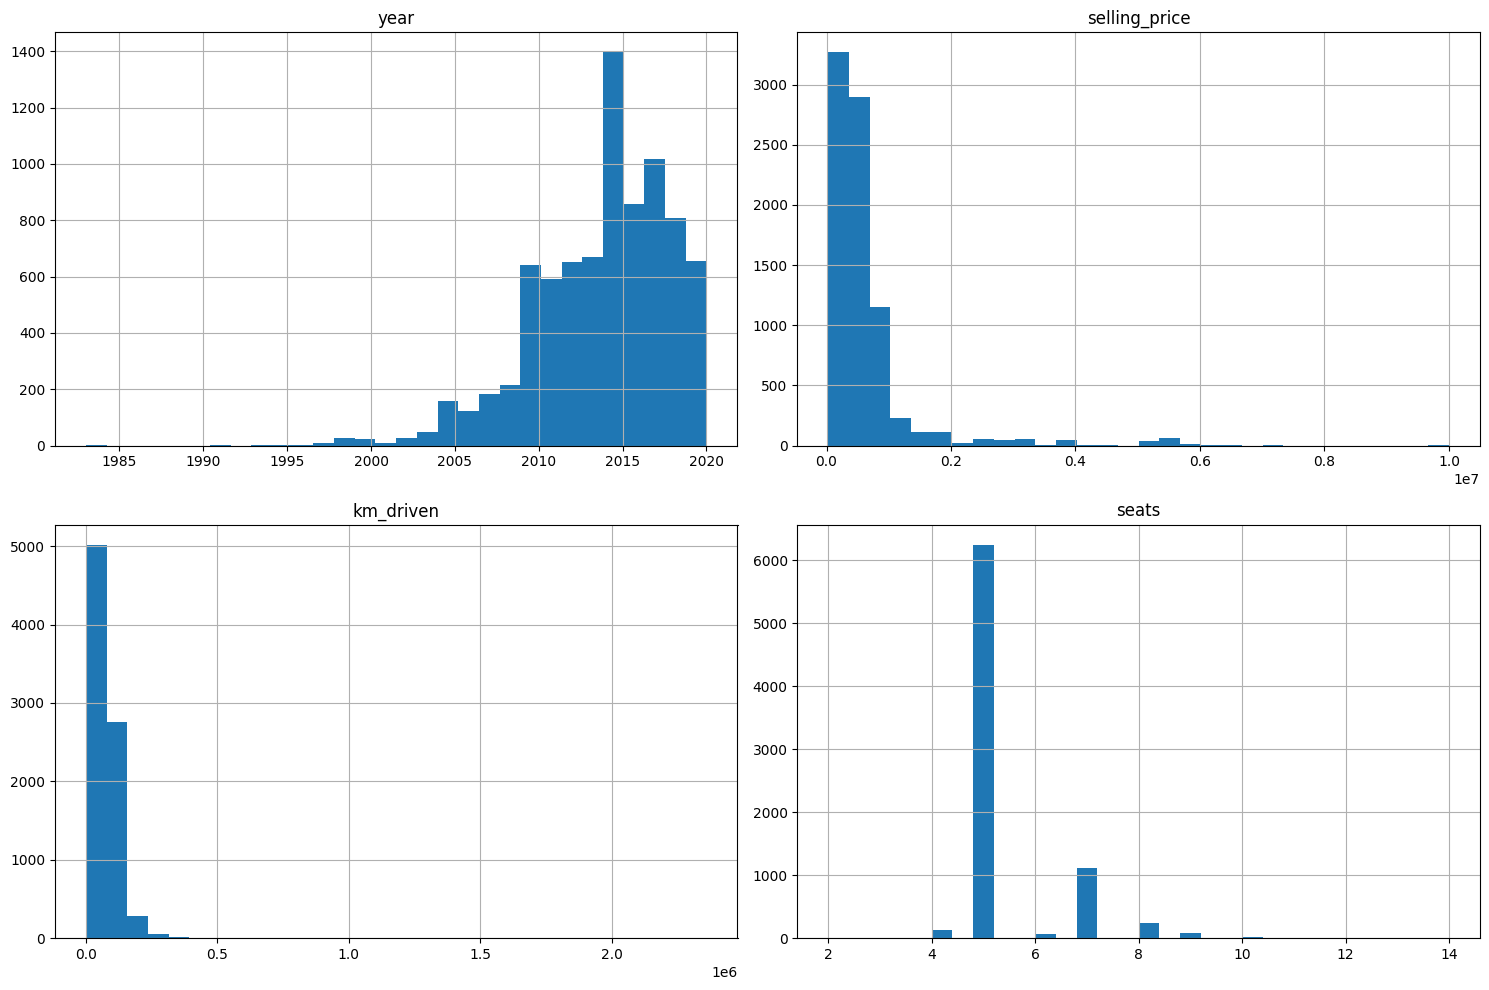

In [9]:
import matplotlib.pyplot as plt
df[num_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()

plt.show()

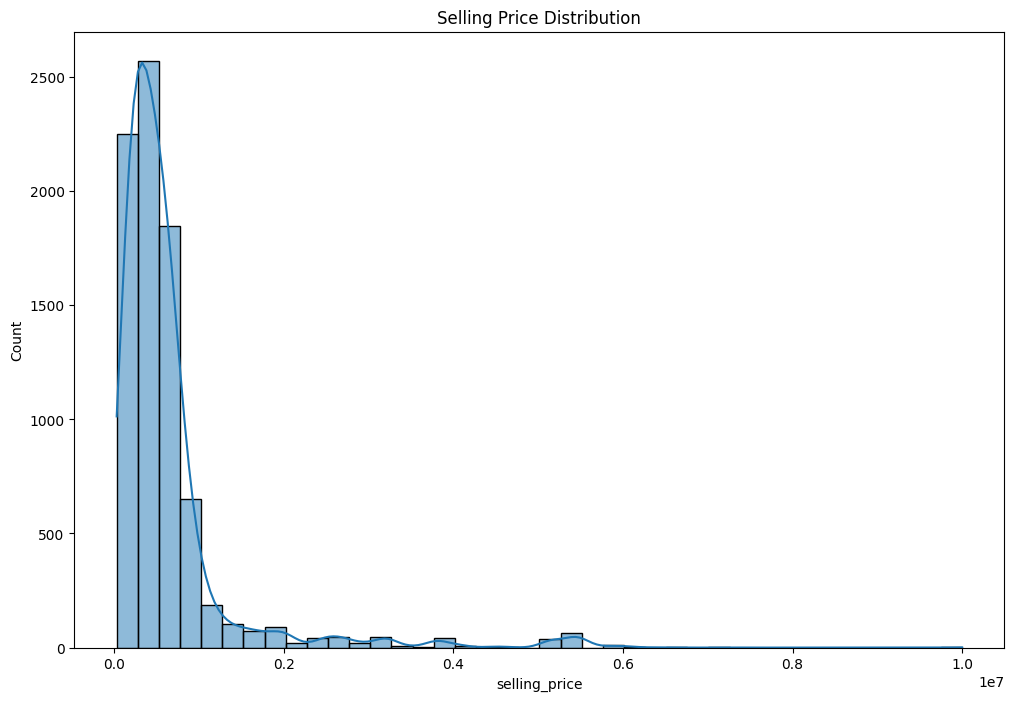

In [10]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.histplot(
    df["selling_price"],
    bins=40,
    kde=True
)
plt.title("Selling Price Distribution")
plt.show()

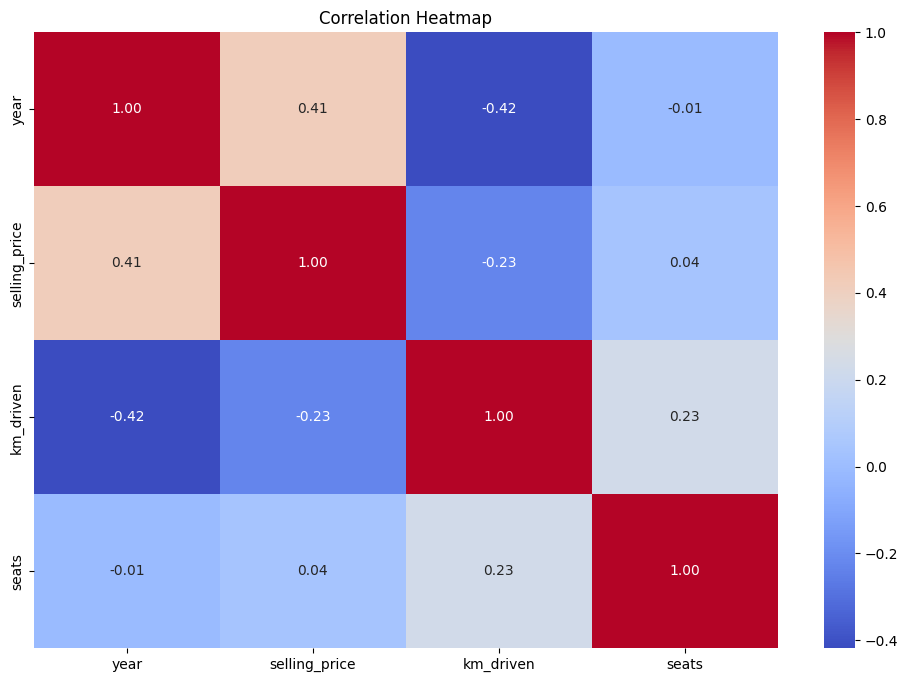

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [12]:
cat_cols = df.select_dtypes(include="object").columns

cat_cols

Index(['name', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage',
       'engine', 'max_power', 'torque'],
      dtype='object')

In [13]:
for col in cat_cols:
    print("="*50)
    print(col)
    print(df[col].value_counts().head(10))

name
name
Maruti Swift Dzire VDI        129
Maruti Alto 800 LXI            82
Maruti Alto LXi                71
BMW X4 M Sport X xDrive20d     62
Maruti Swift VDI               61
Maruti Swift VDI BSIV          59
Maruti Wagon R LXI             53
Maruti Alto K10 VXI            50
Hyundai EON Era Plus           48
Maruti Wagon R VXI BS IV       45
Name: count, dtype: int64
fuel
fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64
seller_type
seller_type
Individual          6766
Dealer              1126
Trustmark Dealer     236
Name: count, dtype: int64
transmission
transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64
owner
owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64
mileage
mileage
18.9 kmpl     225
19.7 kmpl     173
18.6 kmpl     164
21.1 kmpl     157
17.0 kmpl     133
15.96 kmpl    115
16.1 kmp

In [14]:
duplicates = df[df.duplicated()]

duplicates.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
291,Hyundai Grand i10 Sportz,2017,450000,35000,Petrol,Individual,Manual,First Owner,18.9 kmpl,1197 CC,82 bhp,114Nm@ 4000rpm,5.0
296,Maruti Swift VXI,2012,330000,50000,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,85.8 bhp,114Nm@ 4000rpm,5.0
370,Jaguar XE 2016-2019 2.0L Diesel Prestige,2017,2625000,9000,Diesel,Dealer,Automatic,First Owner,13.6 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
371,Lexus ES 300h,2019,5150000,20000,Petrol,Dealer,Automatic,First Owner,22.37 kmpl,2487 CC,214.56 bhp,202Nm@ 3600-5200rpm,5.0
372,Jaguar XF 2.0 Diesel Portfolio,2017,3200000,45000,Diesel,Dealer,Automatic,First Owner,19.33 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0


In [15]:
duplicates.shape

(1202, 13)

In [16]:
duplicates.sample(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
1130,BMW X4 M Sport X xDrive20d,2019,5500000,8500,Diesel,Dealer,Automatic,First Owner,16.78 kmpl,1995 CC,190 bhp,400Nm@ 1750-2500rpm,5.0
6888,Maruti Vitara Brezza ZDi Plus Dual Tone,2018,950000,25000,Diesel,Individual,Manual,First Owner,24.3 kmpl,1248 CC,88.5 bhp,200Nm@ 1750rpm,5.0
4395,Isuzu MUX 2WD,2019,2700000,10000,Diesel,Individual,Automatic,First Owner,13.8 kmpl,2999 CC,174.57 bhp,380NM@ 1800-2800rpm,7.0
3460,Maruti Zen Estilo 1.1 LX BSIII,2007,70000,80000,Petrol,Individual,Manual,Second Owner,18.2 kmpl,1061 CC,64 bhp,84Nm@ 3500rpm,5.0
7555,Hyundai EON Era Plus,2014,250000,80000,Petrol,Individual,Manual,Second Owner,21.1 kmpl,814 CC,55.2 bhp,74.5Nm@ 4000rpm,5.0
6106,Ford Ecosport 1.5 Diesel Titanium,2016,725000,30000,Diesel,Individual,Manual,First Owner,21.7 kmpl,1498 CC,98.96 bhp,215Nm@ 1750-2500rpm,5.0
4353,Mahindra TUV 300 mHAWK100 T8,2017,660000,67000,Diesel,Individual,Manual,Second Owner,18.49 kmpl,1493 CC,100 bhp,240Nm@ 1600-2800rpm,7.0
7491,Honda Mobilio RS Option i DTEC,2015,1000000,46000,Diesel,Individual,Manual,First Owner,24.5 kmpl,1498 CC,98.6 bhp,200Nm@ 1750rpm,7.0
1079,Jaguar XF 2.0 Diesel Portfolio,2017,3200000,45000,Diesel,Dealer,Automatic,First Owner,19.33 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
4243,Toyota Innova 2.5 VX (Diesel) 7 Seater,2013,750000,79328,Diesel,Trustmark Dealer,Manual,Second Owner,12.99 kmpl,2494 CC,100.6 bhp,200Nm@ 1200-3600rpm,7.0


#  Feature Engineering

Several important features are stored as text rather than numerical values.

Examples include:

- Mileage → "18.9 kmpl"
- Engine → "1248 CC"
- Max Power → "88.5 bhp"
- Torque → "190Nm@2000rpm"

These features are converted into numerical values to improve model performance.

Additionally, the torque feature is separated into two meaningful numerical variables:

- Torque (Nm)
- Engine RPM

In [17]:
df["mileage"] = (
    df["mileage"]
    .str.replace(" kmpl","",regex=False)
    .str.replace(" km/kg","",regex=False)
)

df["mileage"] = pd.to_numeric(df["mileage"],errors="coerce")

In [18]:
df["engine"] = (
    df["engine"]
    .str.replace(" CC","",regex=False)
)

df["engine"] = pd.to_numeric(df["engine"],errors="coerce")

In [19]:
df["max_power"] = (
    df["max_power"]
    .str.replace(" bhp","",regex=False)
)

df["max_power"] = pd.to_numeric(df["max_power"],errors="coerce")

In [20]:
df["torque"].sample(20)

1604            96.1Nm@ 3000rpm
5019             200Nm@ 1750rpm
2829        400Nm@ 1750-2500rpm
3283             171Nm@ 1800rpm
3296        200Nm@ 1200-3600rpm
3820           135.4Nm@ 2500rpm
770     260 Nm at 1800-2200 rpm
5943             200Nm@ 1750rpm
893              160Nm@ 2000rpm
102              113Nm@ 4200rpm
5901                        NaN
7646        260Nm@ 1500-2750rpm
4928      219.6Nm@ 1500-2750rpm
5096     190.24nm@ 1750-2250rpm
2810              59Nm@ 2500rpm
1748        450Nm@ 1600-2400rpm
6733        140Nm@ 1800-3000rpm
2482           114.7Nm@ 4000rpm
714         240Nm@ 1600-2800rpm
2974          146Nm at 4800 rpm
Name: torque, dtype: object

In [21]:
df["torque_nm"] = (
    df["torque"]
    .str.extract(r'([\d\.]+)')
)

df["torque_nm"] = pd.to_numeric(
    df["torque_nm"],
    errors="coerce"
)

In [22]:
df["rpm"] = (
    df["torque"]
    .str.extract(r'@\s*([\d\.]+)')
)

df["rpm"] = pd.to_numeric(
    df["rpm"],
    errors="coerce"
)

#  Handling Missing Values

The remaining missing values occur primarily in numerical columns.

Median imputation is selected because it is robust against skewed distributions and outliers while preserving most of the dataset.

In [23]:
df.drop(columns="torque",inplace=True)

In [24]:
df.info()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   float64
 9   engine         7907 non-null   float64
 10  max_power      7912 non-null   float64
 11  seats          7907 non-null   float64
 12  torque_nm      7906 non-null   float64
 13  rpm            7641 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 889.1+ KB


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,torque_nm,rpm
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,190.0,2000.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,250.0,1500.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,12.7,2.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,22.4,NaN
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,11.5,4.0


In [25]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

rpm          487
torque_nm    222
mileage      221
engine       221
seats        221
max_power    216
dtype: int64

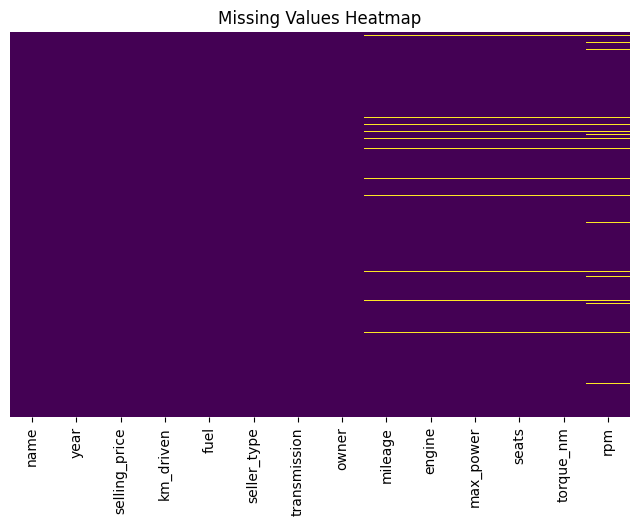

In [26]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

In [27]:
num_missing_cols = [
    "mileage",
    "engine",
    "max_power",
    "torque_nm",
    "rpm",
    "seats"
]

for col in num_missing_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_58/2915333644.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [28]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
torque_nm        0
rpm              0
dtype: int64

#  Feature Selection

The selling price is selected as the target variable.

The remaining columns are treated as predictive features.

In [29]:
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

In [30]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

cat_features = X.select_dtypes(include="object").columns.tolist()

print("Numerical Features:")
print(num_features)

print("\nCategorical Features:")
print(cat_features)

Numerical Features:
['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'torque_nm', 'rpm']

Categorical Features:
['name', 'fuel', 'seller_type', 'transmission', 'owner']


#  Train-Test Split

The dataset is divided into training and testing sets.

The training set is used to build the models while the testing set is reserved for evaluating generalization performance.

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#  Data Preprocessing Pipeline

Machine Learning pipelines provide a clean and reproducible workflow.

Categorical variables are encoded using One-Hot Encoding while numerical variables are passed directly to the model.

Using a preprocessing pipeline also prevents data leakage during cross-validation.

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            cat_features
        )
    ],
    remainder="passthrough"
)

#  Model Evaluation Framework

To compare multiple regression models fairly, a reusable evaluation function is created.

Each model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score
- 5-Fold Cross Validation

This ensures every algorithm is trained and evaluated under identical conditions.

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
import numpy as np

results = []

In [42]:
def evaluate_model(name, model):
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model",model)
    ])
    pipeline.fit(X_train,y_train)
    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test,y_pred)
    rmse = np.sqrt(mean_absolute_error(y_test,y_pred))
    r2 = r2_score(y_test,y_pred)
    cv = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    results.append({
        "Model":name,
        "MAE":round(mae, 2),
        "RMSE":round(r2,4),
        "R2":round(r2,4),
        "CV Mean":round(cv.mean(),4),
        "CV Std":round(cv.std(),4)
    })
    print(f"\n{name}")
    print(f"MAE:{mae:.2f}")
    print(f"RMSE:{rmse:.2f}")
    print(f"R2:{r2:.4f}")
    print(f"CV Mean:{cv.mean():.4f}")

#  Linear Regression

Linear Regression serves as the baseline model.

Although simple, it provides an important benchmark against which more advanced ensemble methods can be compared.

In [43]:
from sklearn.linear_model import LinearRegression

evaluate_model(
    "Linear Regression",
    LinearRegression()
)


Linear Regression
MAE:275656.25
RMSE:525.03
R2:0.6839
CV Mean:0.6767


#  Decision Tree Regressor

Decision Trees capture non-linear relationships by recursively partitioning the feature space.

While powerful, individual trees are prone to overfitting, motivating the use of ensemble methods.

In [44]:
from sklearn.tree import DecisionTreeRegressor

evaluate_model(
    "Decision Tree",
    DecisionTreeRegressor(
        random_state=42
    )
)


Decision Tree
MAE:77297.09
RMSE:278.02
R2:0.9540
CV Mean:0.9568


#  Random Forest Regressor

Random Forest combines multiple Decision Trees trained on bootstrap samples.

Advantages include:

- Reduced variance
- Improved generalization
- Better robustness against overfitting

In [46]:
from sklearn.ensemble import RandomForestRegressor

evaluate_model(
    "Random Forest",
    RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
)


Random Forest
MAE:64710.47
RMSE:254.38
R2:0.9739
CV Mean:0.9668


#  Extra Trees Regressor

Extra Trees introduces additional randomness during tree construction by selecting split thresholds randomly.

This often results in:

- Faster training
- Lower variance
- Excellent predictive performance on structured datasets

In [47]:
from sklearn.ensemble import ExtraTreesRegressor

evaluate_model(
    "Extra Trees Regressor",
    ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
)


Extra Trees Regressor
MAE:60285.72
RMSE:245.53
R2:0.9775
CV Mean:0.9689


#  AdaBoost Regressor

AdaBoost sequentially builds weak learners where each new model focuses more on correcting previous prediction errors.

Although effective in some regression tasks, it may struggle compared to Gradient Boosting methods on complex datasets.

In [48]:
from sklearn.ensemble import AdaBoostRegressor

evaluate_model(
    "AdaBoost Regressor",
    AdaBoostRegressor(
        random_state=42,
        n_estimators=200,
        learning_rate=0.5
    )
)


AdaBoost Regressor
MAE:386565.23
RMSE:621.74
R2:0.7221
CV Mean:0.8157


#  Gradient Boosting Regressor

Gradient Boosting constructs trees sequentially, with each tree learning from the residual errors of the previous ensemble.

This approach often achieves high predictive accuracy on structured data.

In [49]:
from sklearn.ensemble import GradientBoostingRegressor

evaluate_model(
    "Gradient Boosting Regressor",
    GradientBoostingRegressor(random_state=42)
)


Gradient Boosting Regressor
MAE:96606.43
RMSE:310.82
R2:0.9609
CV Mean:0.9540


#  Histogram Gradient Boosting

Histogram Gradient Boosting is an optimized implementation of Gradient Boosting.

Continuous variables are first grouped into histograms, significantly reducing training time while maintaining excellent predictive performance.

In [52]:
from sklearn.ensemble import HistGradientBoostingRegressor
evaluate_model(
    "HistGradient Boosting Regressor",
    HistGradientBoostingRegressor(random_state=42)
)


HistGradient Boosting Regressor
MAE:73266.87
RMSE:270.68
R2:0.9676
CV Mean:0.9613


#  Model Comparison

All trained regression models are compared using identical evaluation metrics.

Metrics considered:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score
- Cross Validation Mean
- Cross Validation Standard Deviation

The best model is selected based on predictive performance and generalization ability.

In [53]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2,CV Mean,CV Std
3,Extra Trees Regressor,60285.72,0.9775,0.9775,0.9689,0.0122
2,Random Forest,64710.47,0.9739,0.9739,0.9668,0.0104
6,HistGradient Boosting Regressor,73266.87,0.9676,0.9676,0.9613,0.0169
5,Gradient Boosting Regressor,96606.43,0.9609,0.9609,0.9540,0.0112
1,Decision Tree,77297.09,0.9540,0.9540,0.9568,0.0107
4,AdaBoost Regressor,386565.23,0.7221,0.7221,0.8157,0.0281
0,Linear Regression,275656.25,0.6839,0.6839,0.6767,0.0142


#  Conclusion

Among all evaluated regression models:

- Extra Trees Regressor achieved the highest predictive performance.
- Random Forest and Histogram Gradient Boosting also demonstrated excellent generalization.
- Linear Regression underperformed due to the non-linear nature of the dataset.

The consistently high cross-validation scores indicate that the ensemble methods generalize well without significant overfitting.

Overall, tree-based ensemble learning proved highly effective for predicting used car selling prices.

# Feature Importance

Understanding which features contribute most to the prediction is just as important as achieving high predictive performance.

Tree-based ensemble models provide feature importance scores, allowing us to identify the variables that have the greatest influence on the selling price of a used car.

This improves both model interpretability and business understanding.

In [54]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

best_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['name', 'fuel',
                                                   'seller_type',
                                                   'transmission',
                                                   'owner'])])),
                ('model',
                 ExtraTreesRegressor(n_estimators=300, n_jobs=-1,
                                     random_state=42))])

In [56]:
ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"]

encoded_features = ohe.get_feature_names_out(cat_features)

feature_names = np.concatenate([
    encoded_features,
    num_features
])

In [57]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.named_steps["model"].feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
1908,max_power,0.206879
1910,torque_nm,0.142172
1898,transmission_Manual,0.131228
1897,transmission_Automatic,0.126540
43,name_BMW X4 M Sport X xDrive20d,0.094363
1904,year,0.093729
740,name_Lexus ES 300h,0.043803
1907,engine,0.039509
1905,km_driven,0.021347
1899,owner_First Owner,0.011532


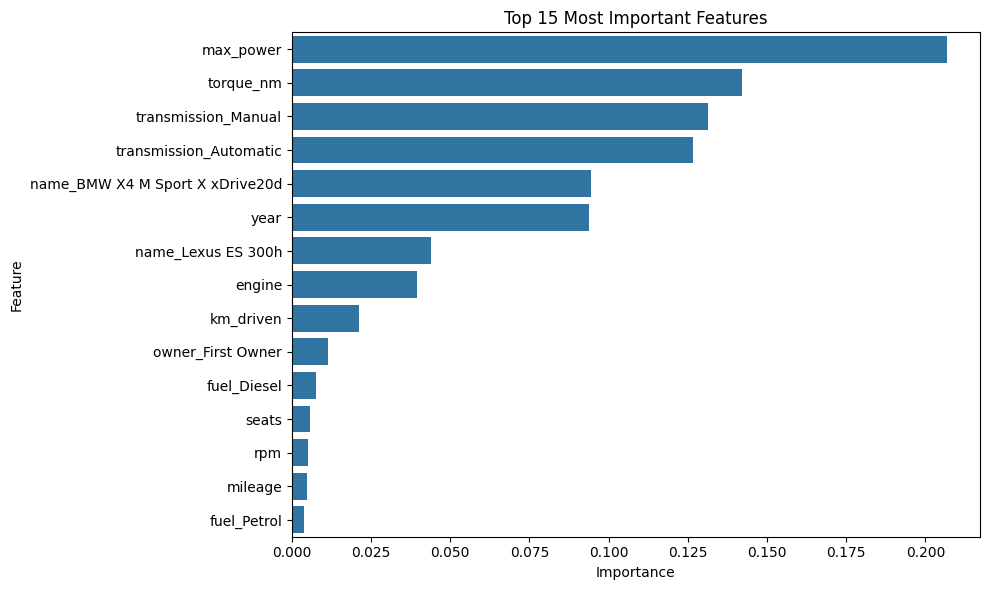

In [58]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features")

plt.tight_layout()

plt.show()

#  Actual vs Predicted Prices

A well-performing regression model should produce predictions that closely follow the actual selling prices.

If the predictions perfectly match the observations, all points would lie on the diagonal line.

In [59]:
y_pred = best_model.predict(X_test)

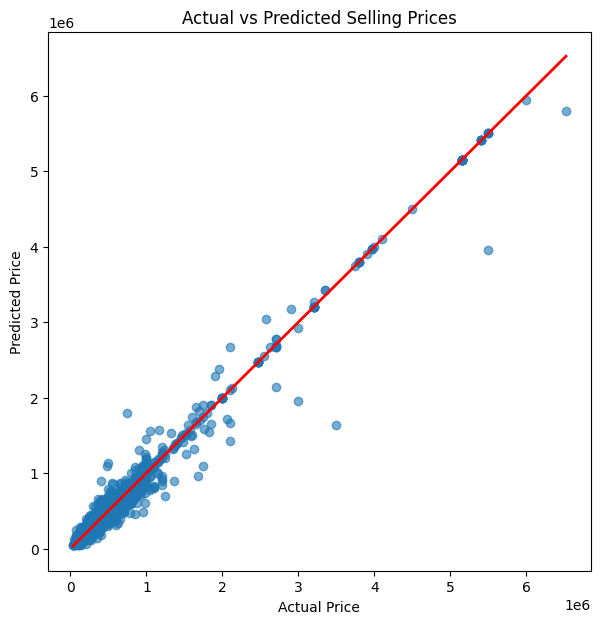

In [60]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Selling Prices")

plt.show()

#  Residual Analysis

Residuals represent the difference between the actual and predicted values.

A good regression model should produce residuals that are:

- Centered around zero
- Randomly distributed
- Free from obvious patterns

Systematic patterns in the residuals may indicate bias or missing relationships in the model.

In [61]:
residuals = y_test - y_pred

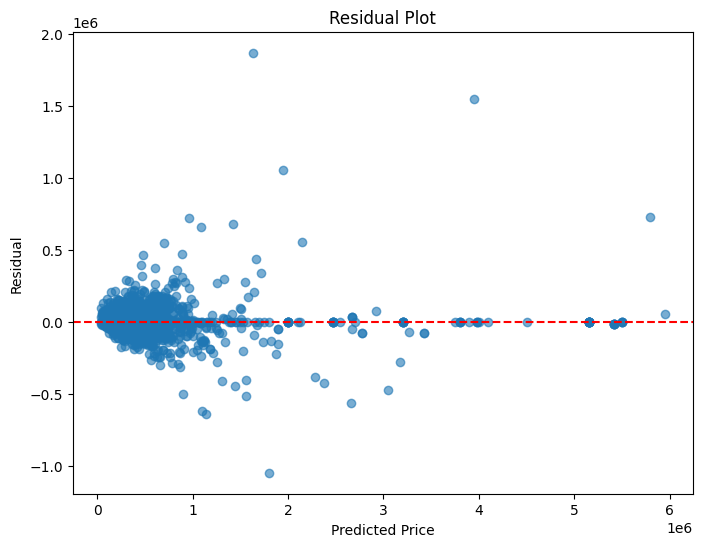

In [62]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

#  Final Remarks

This project demonstrates a complete machine learning workflow for used car price prediction, covering:

- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Missing Value Handling
- Preprocessing Pipelines
- Multiple Regression Algorithms
- Ensemble Learning
- Cross Validation
- Model Comparison
- Feature Importance Analysis
- Residual Analysis

Among all evaluated models, the **Extra Trees Regressor** achieved the highest predictive performance with excellent generalization, making it the final selected model for this problem.